# Results & Interpretability Analysis

**Phase 1** (architecture comparison): training curves, test-set metrics, and confusion matrices for all 3 models from `results/figures/` and `results/checkpoints/`.

**Phase 2** (optimized RoBERTa): optimized RoBERTa confusion matrix and interpretability (embeddings, attention, feature attribution) from `results/figures_optimized/`.

Run from project root, or the first cell will `chdir` to parent if you are in `notebooks/`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/junhohong/Desktop/stat359/student/final_project


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

sns.set_theme(style='whitegrid', font_scale=1.2)
FIG_DIR = Path('results/figures')           # Phase 1: all 3 models
FIG_DIR_OPT = Path('results/figures_optimized')  # Phase 2: optimized RoBERTa only
CKPT_DIR = Path('results/checkpoints')
MODEL_NAMES = {'roberta': 'RoBERTa', 'gpt2': 'GPT-2', 't5': 'T5'}
GENRE_NAMES_MAP = {0: 'Rap/Hip-Hop', 1: 'Pop', 2: 'Rock', 3: 'Country', 4: 'R&B'}

## 1. Training Curves

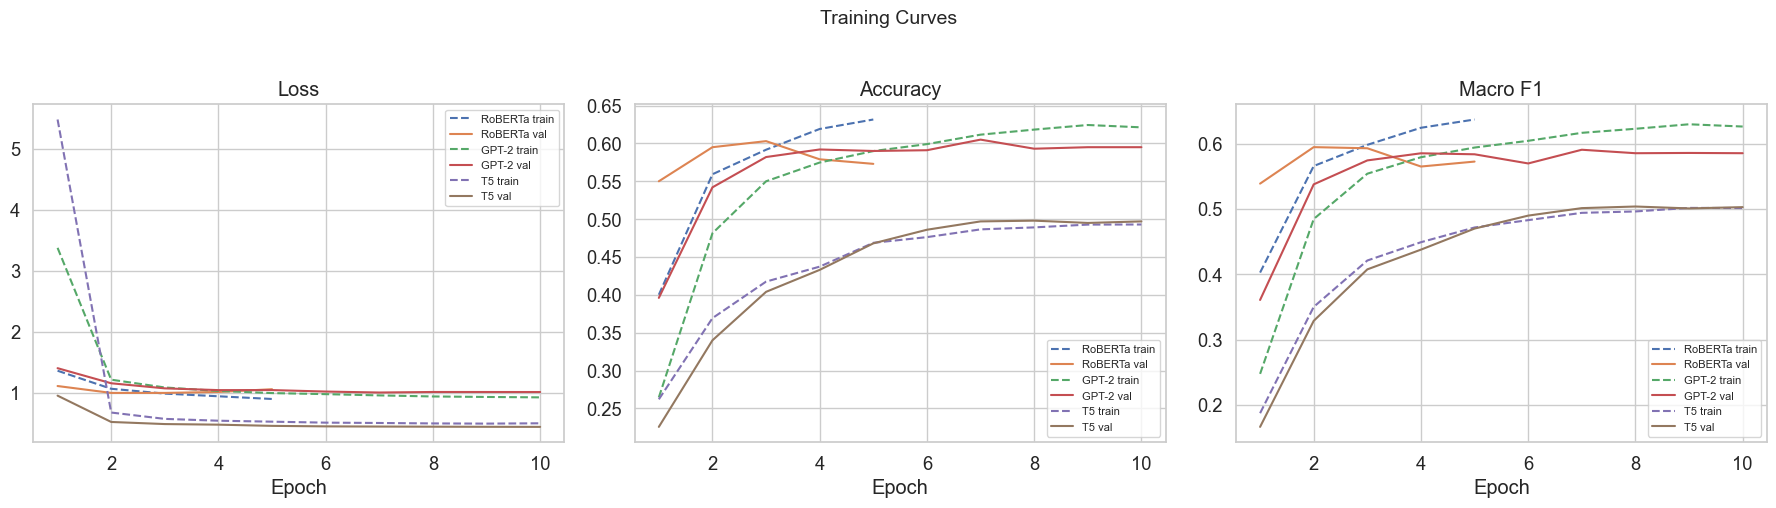

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = [('train_loss', 'val_loss', 'Loss'),
                   ('train_acc', 'val_acc', 'Accuracy'),
                   ('train_f1', 'val_f1', 'Macro F1')]

for model_key, display_name in MODEL_NAMES.items():
    hist_path = CKPT_DIR / model_key / 'history.json'
    if not hist_path.exists():
        print(f'  Skipping {model_key} (no history file)')
        continue
    with open(hist_path) as f:
        hist = json.load(f)
    epochs = range(1, len(hist['train_loss']) + 1)

    for ax, (train_k, val_k, title) in zip(axes, metrics_to_plot):
        ax.plot(epochs, hist[train_k], label=f'{display_name} train', linestyle='--')
        ax.plot(epochs, hist[val_k], label=f'{display_name} val')
        ax.set_title(title)
        ax.set_xlabel('Epoch')

for ax in axes:
    ax.legend(fontsize=8)
plt.suptitle('Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Test-Set Performance Comparison

{
  "roberta": {
    "accuracy": 0.613,
    "f1_macro": 0.6110703746026684,
    "f1_weighted": 0.6110703746026684
  },
  "gpt2": {
    "accuracy": 0.604,
    "f1_macro": 0.5909800187541512,
    "f1_weighted": 0.5909800187541512
  },
  "t5": {
    "accuracy": 0.454,
    "f1_macro": 0.4630965784244986,
    "f1_weighted": 0.46309657842449853
  }
}


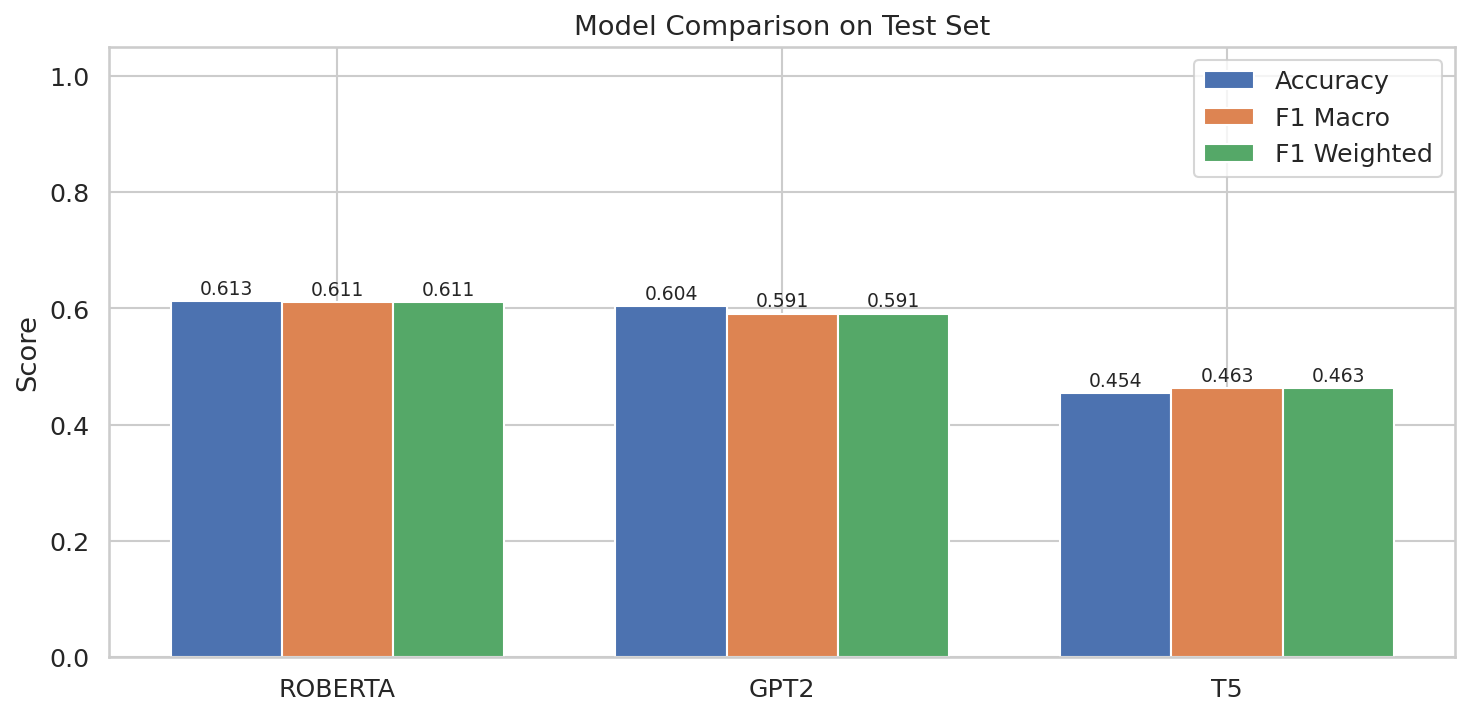

In [4]:
results_path = FIG_DIR / 'test_results.json'
if results_path.exists():
    with open(results_path) as f:
        results = json.load(f)
    print(json.dumps(results, indent=2))

    # Bar chart
    display(Image(filename=str(FIG_DIR / 'model_comparison.png')))
else:
    print('Run src/evaluate.py first to generate test results.')

## 3. Confusion Matrices

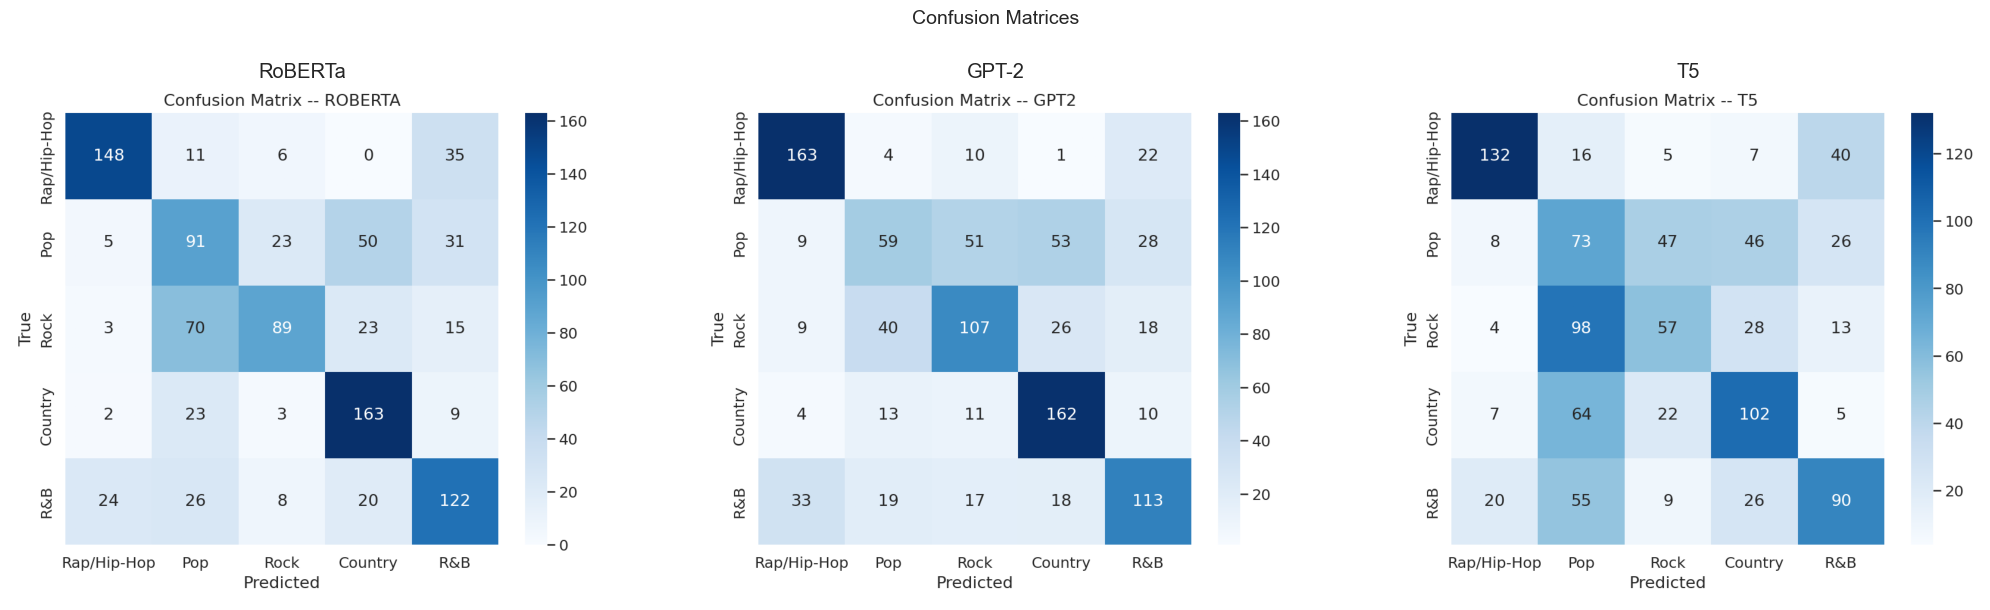

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (model_key, display_name) in zip(axes, MODEL_NAMES.items()):
    cm_path = FIG_DIR / f'cm_{model_key}.png'
    if cm_path.exists():
        img = plt.imread(str(cm_path))
        ax.imshow(img)
        ax.set_title(display_name)
    else:
        ax.text(0.5, 0.5, 'Not available', ha='center', va='center')
        ax.set_title(display_name)
    ax.axis('off')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Phase 2: Optimized RoBERTa

Confusion matrix for the RoBERTa model trained with the optimized config (saved by Colab or `scripts/cluster/04_phase2.sh`).

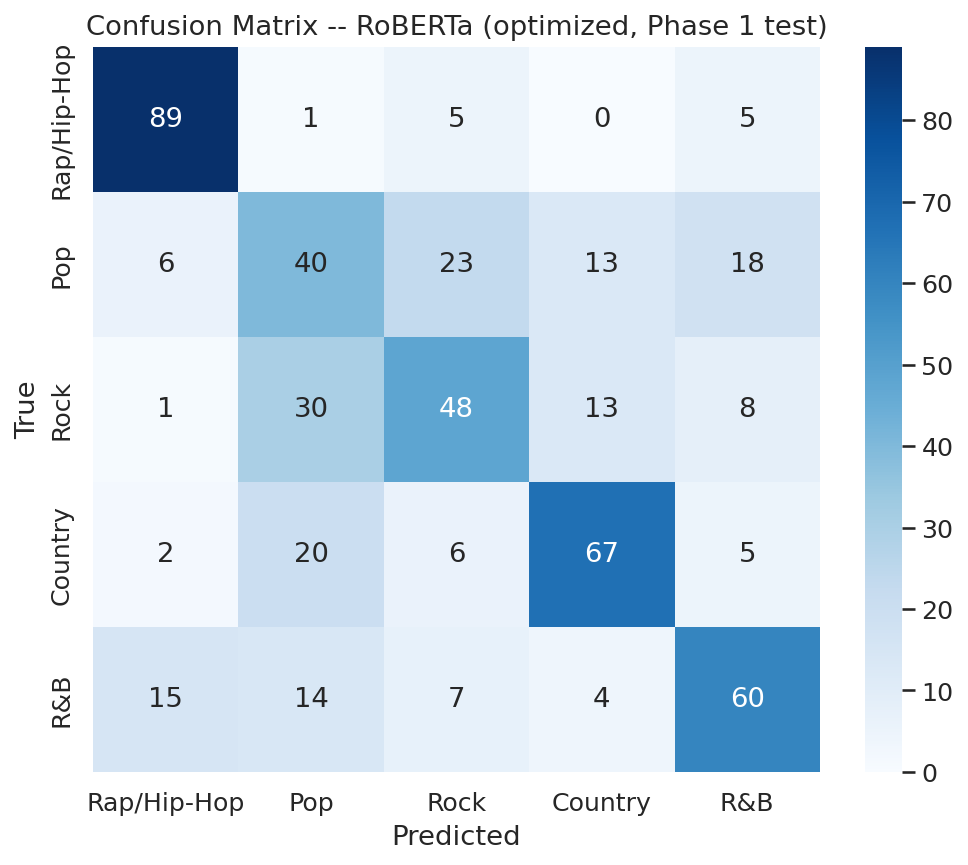

In [6]:
cm_opt = FIG_DIR_OPT / 'cm_roberta_optimized.png'
if cm_opt.exists():
    display(Image(filename=str(cm_opt), width=500))
else:
    print('Run Phase 2 (optimized RoBERTa) training + evaluation to generate this figure.')

## 5. Embedding Visualizations (Phase 2 — Optimized RoBERTa)

UMAP and t-SNE of RoBERTa test-set embeddings from `results/figures_optimized/` (produced by Colab Phase 2 or interpretability scripts).

--- UMAP (RoBERTa optimized) ---


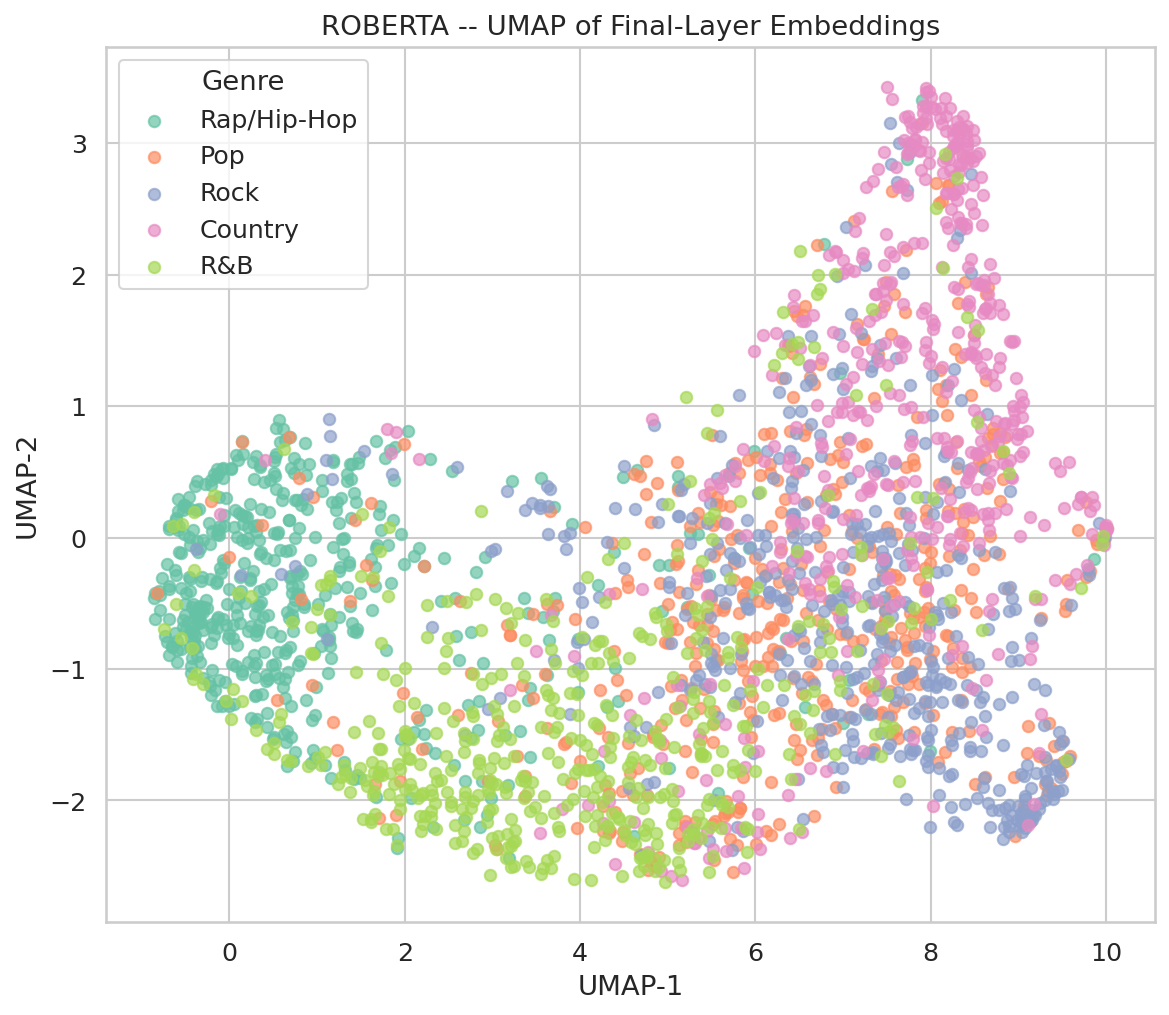

  TSNE not found in results/figures_optimized. Run Phase 2 interpretability.


In [7]:
# Phase 2: optimized RoBERTa embeddings (Colab writes here)
for method in ['umap', 'tsne']:
    path = FIG_DIR_OPT / f'{method}_roberta.png'
    if path.exists():
        print(f'--- {method.upper()} (RoBERTa optimized) ---')
        display(Image(filename=str(path), width=600))
    else:
        print(f'  {method.upper()} not found in {FIG_DIR_OPT}. Run Phase 2 interpretability.')

## 6. Contrastive Analysis (Phase 2 — Optimized RoBERTa)

Contrastive Integrated Gradients highlights which tokens push the model toward one genre over another for confused genre pairs. The confusion analysis identifies the highest-error pairs, and vocabulary plots show the top tokens distinguishing confused genres.

--- Confusion Pair Analysis ---


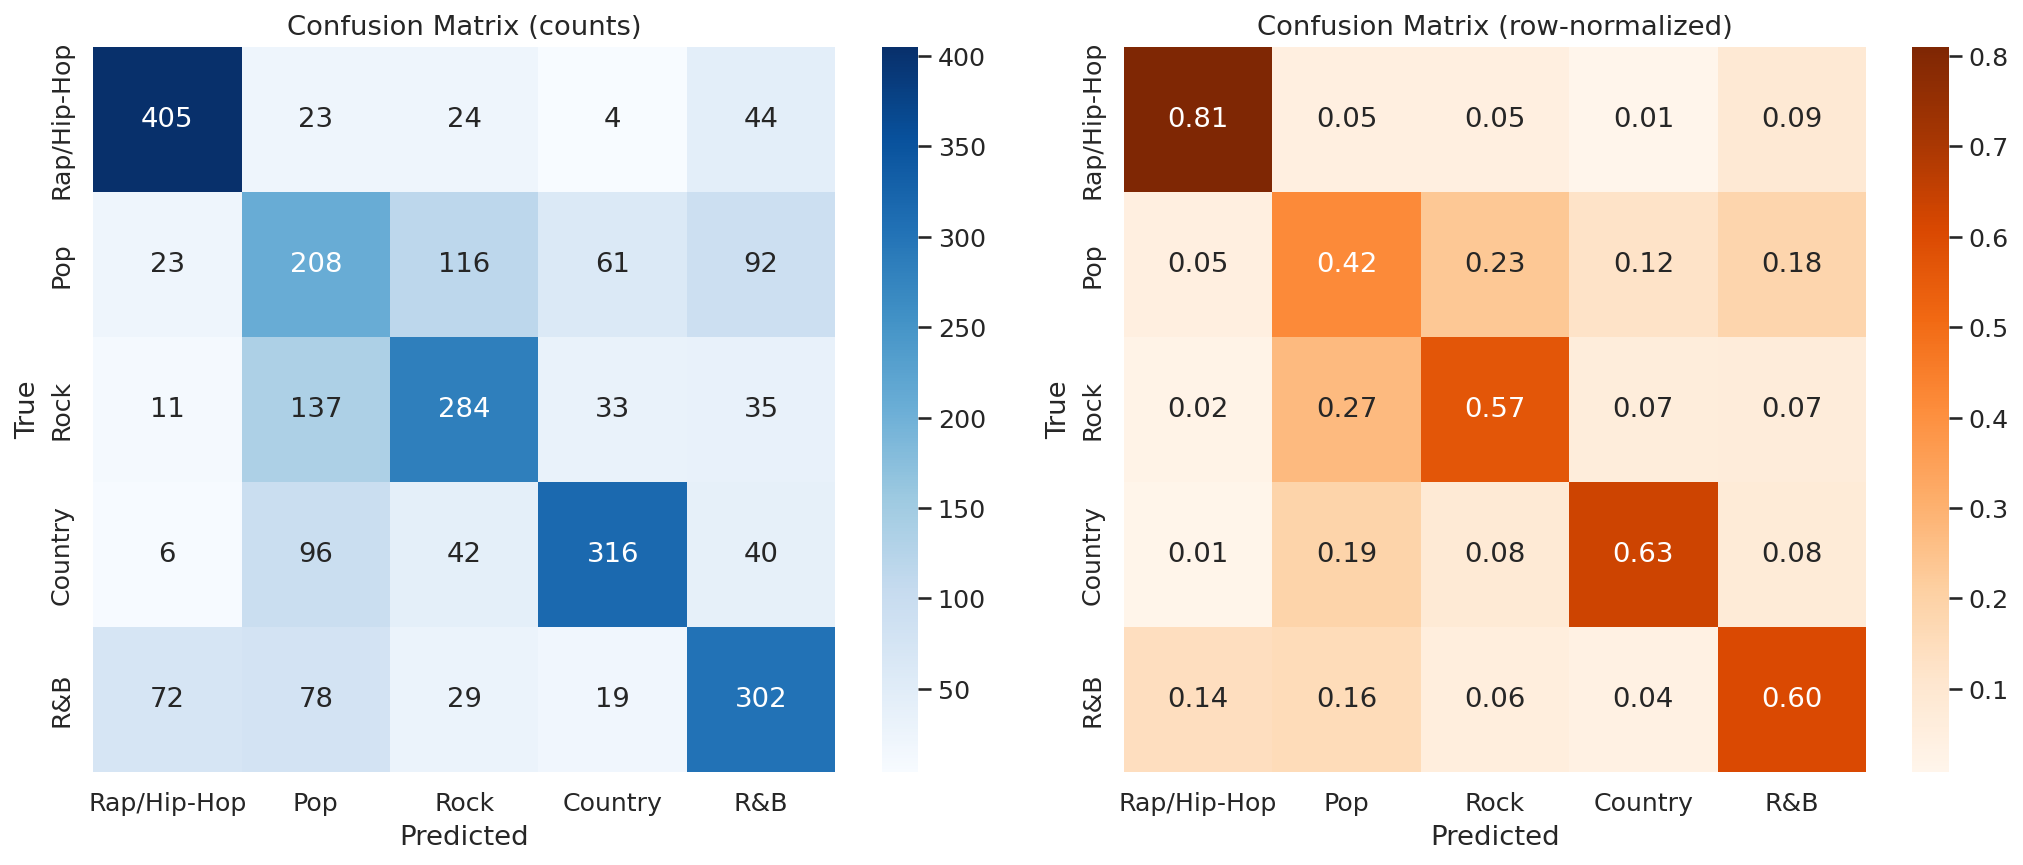


--- Contrastive Vocabulary: Country vs Pop ---


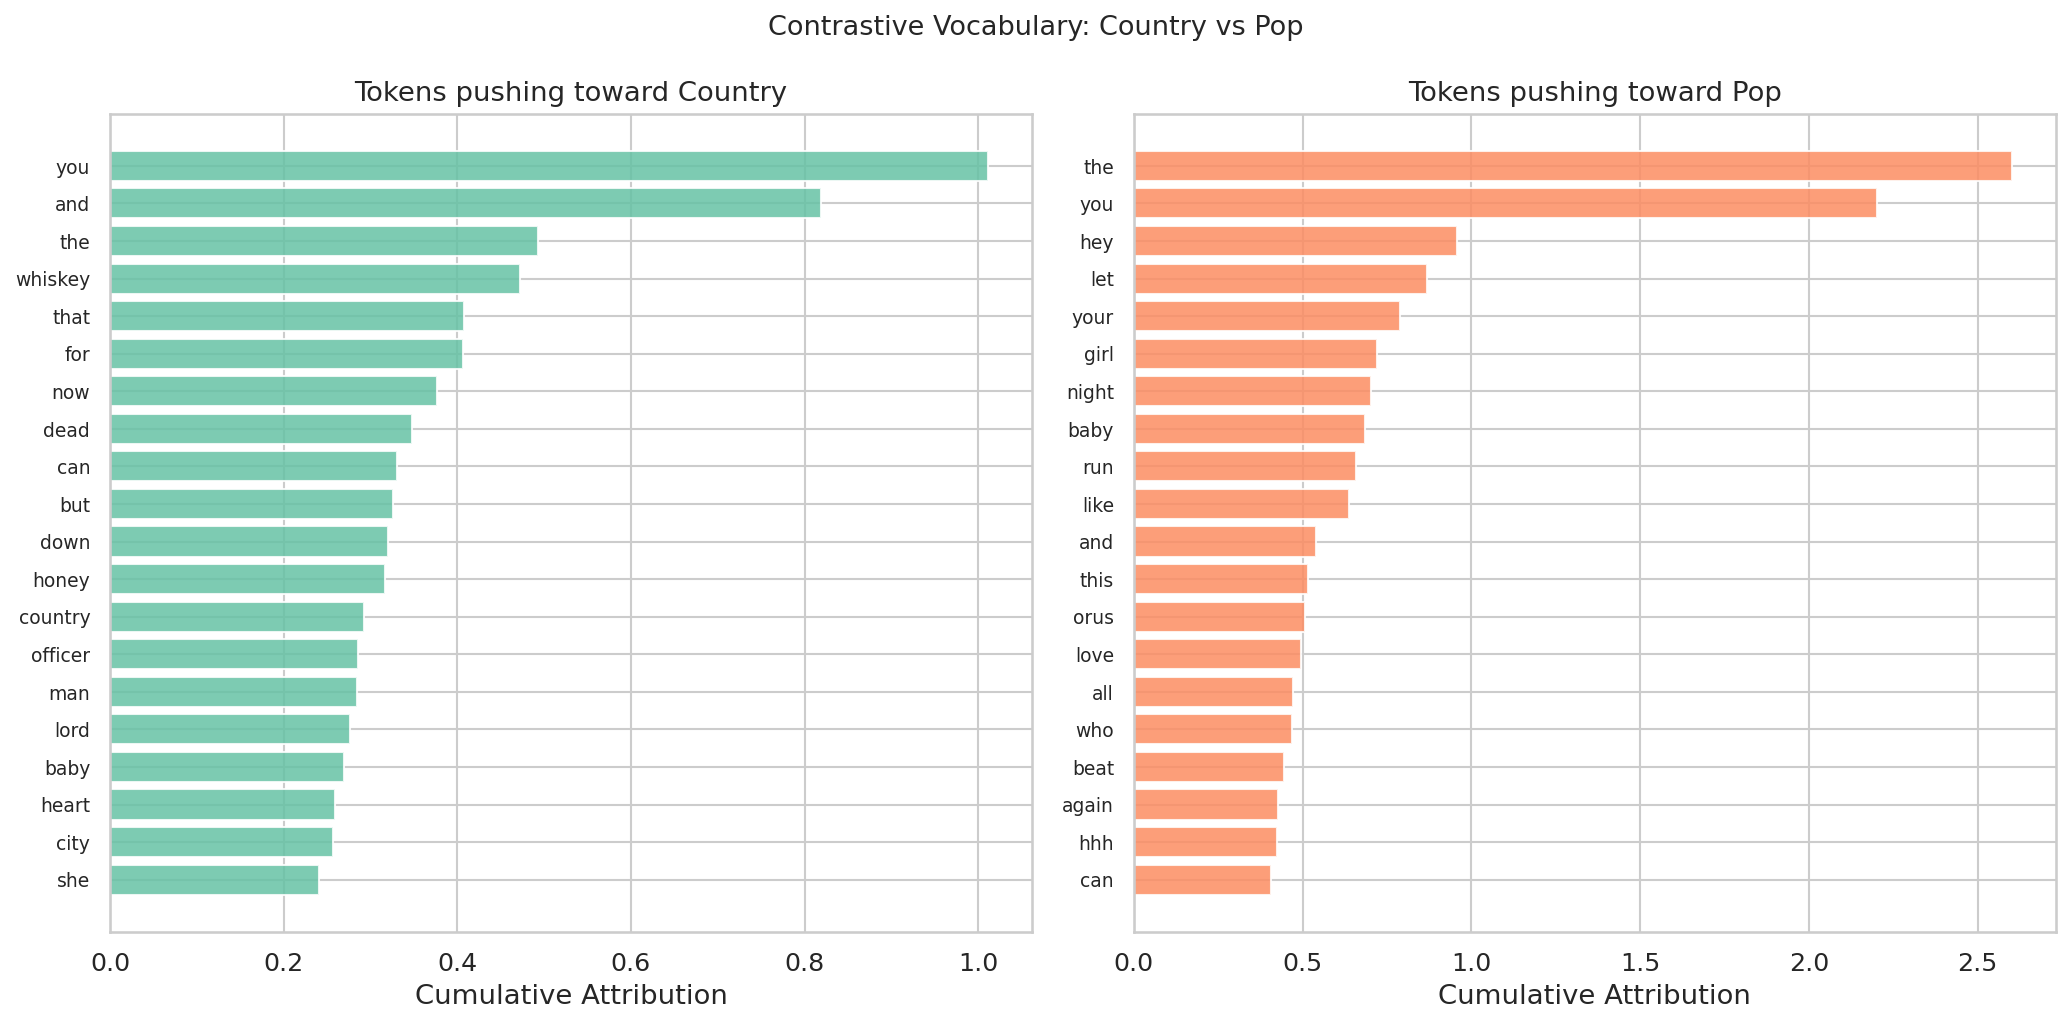


--- Contrastive Vocabulary: Pop vs Rock ---


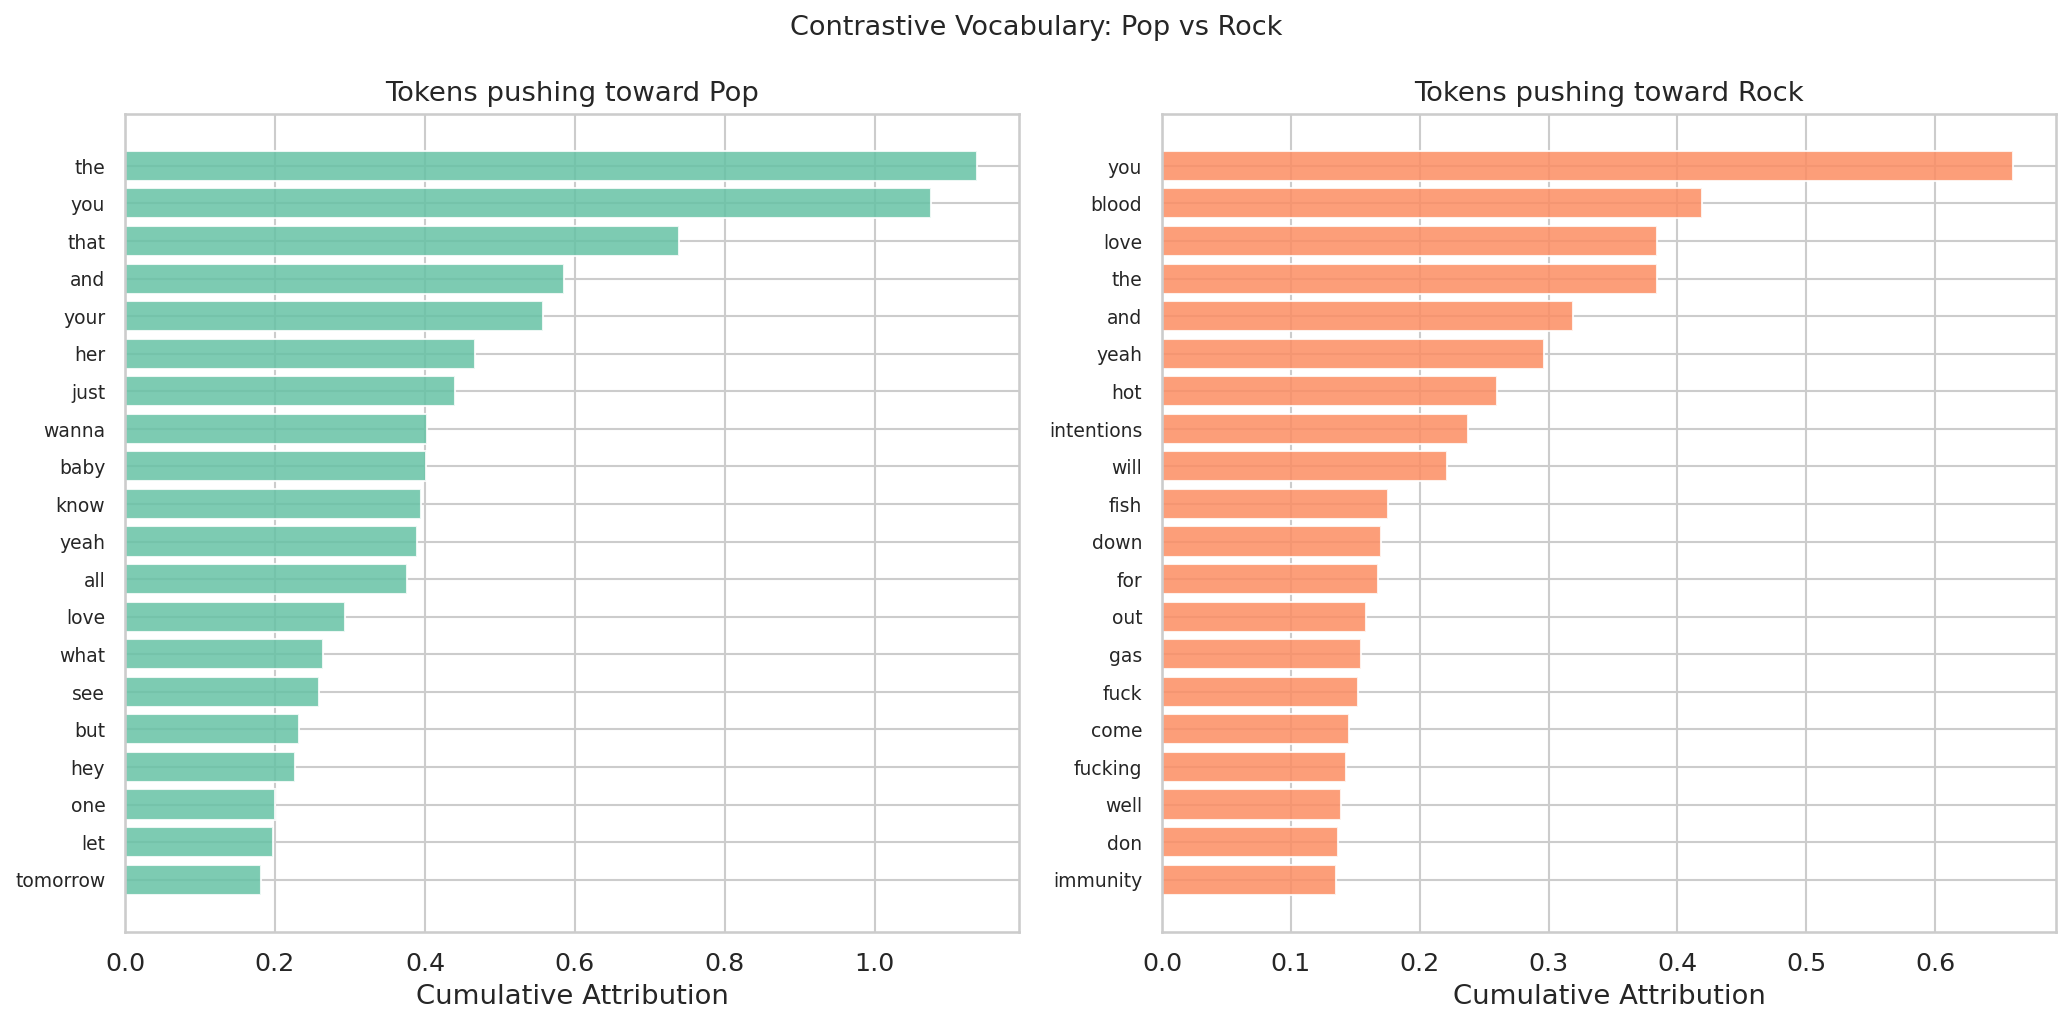


--- Contrastive Vocabulary: Rock vs Pop ---


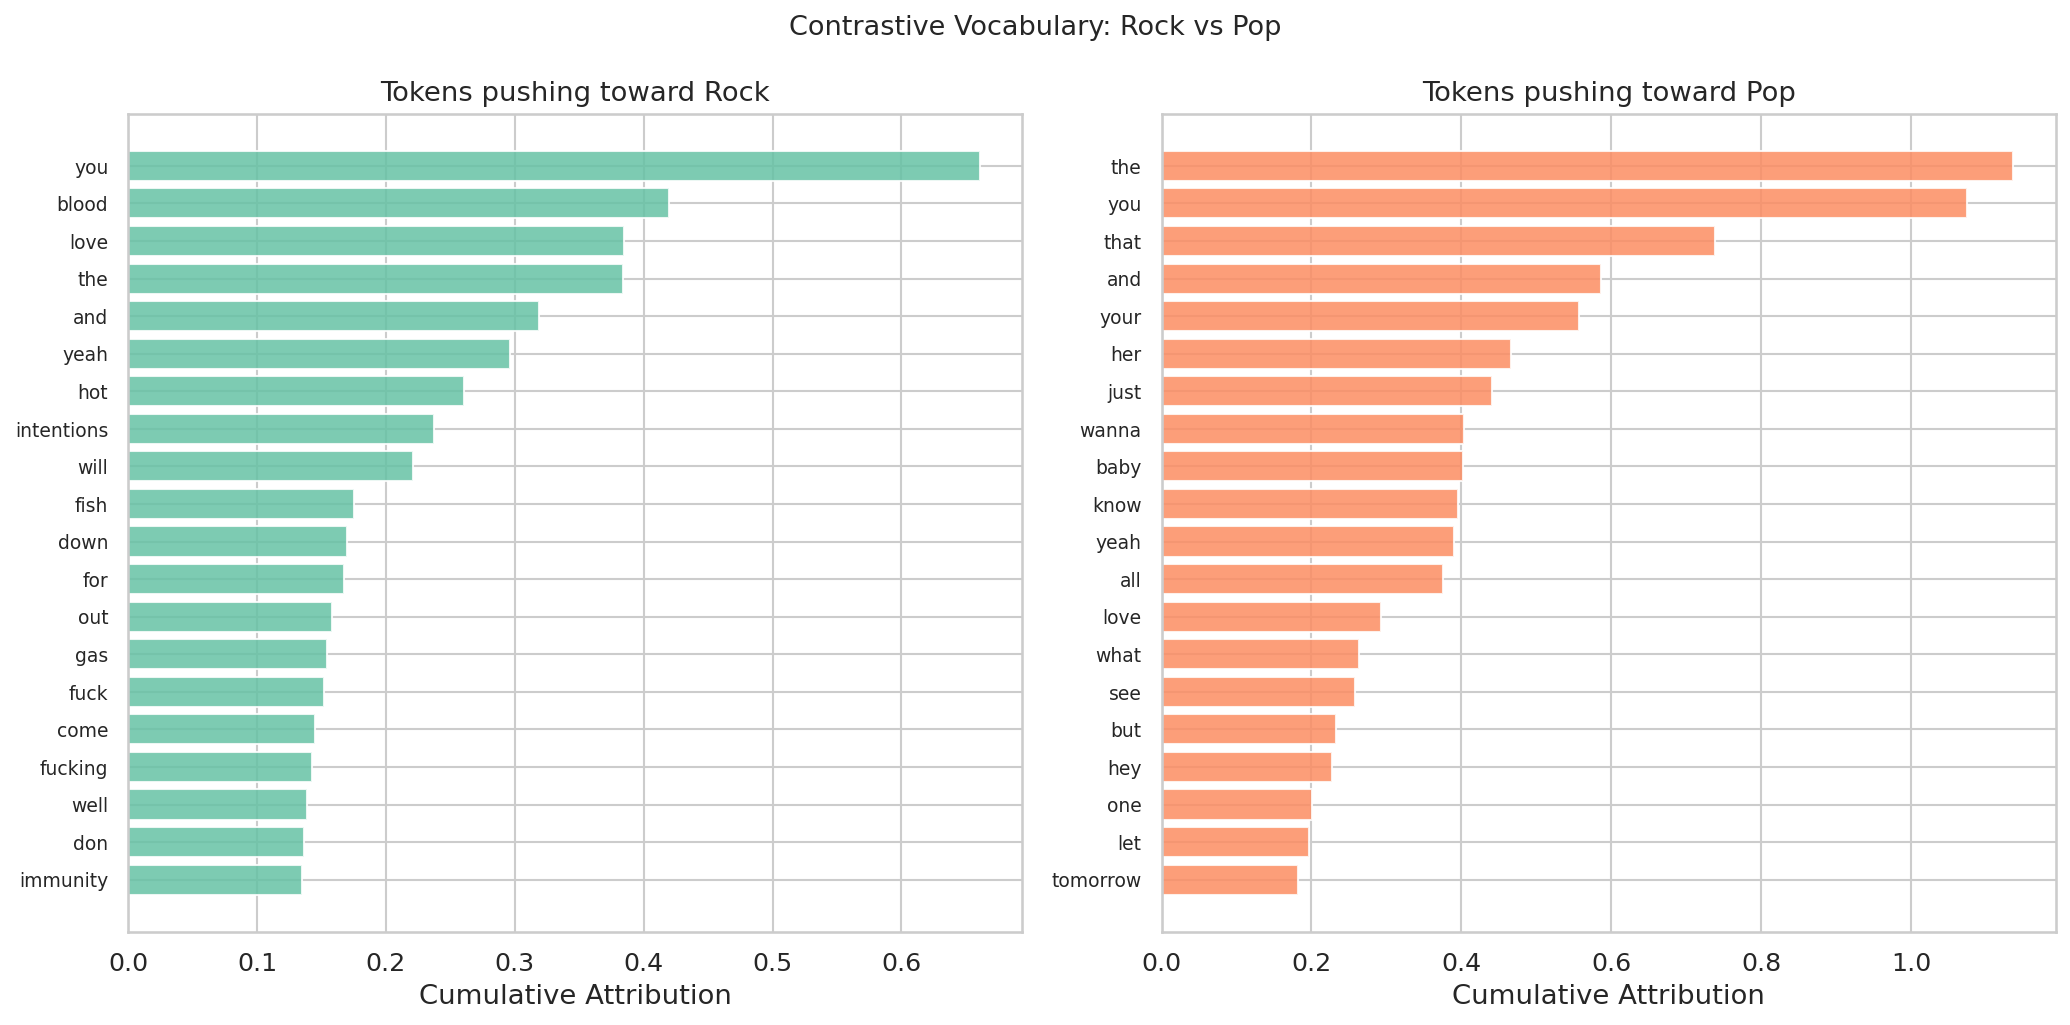


--- Misclassification Examples (Token Attribution) ---

Country vs Pop:


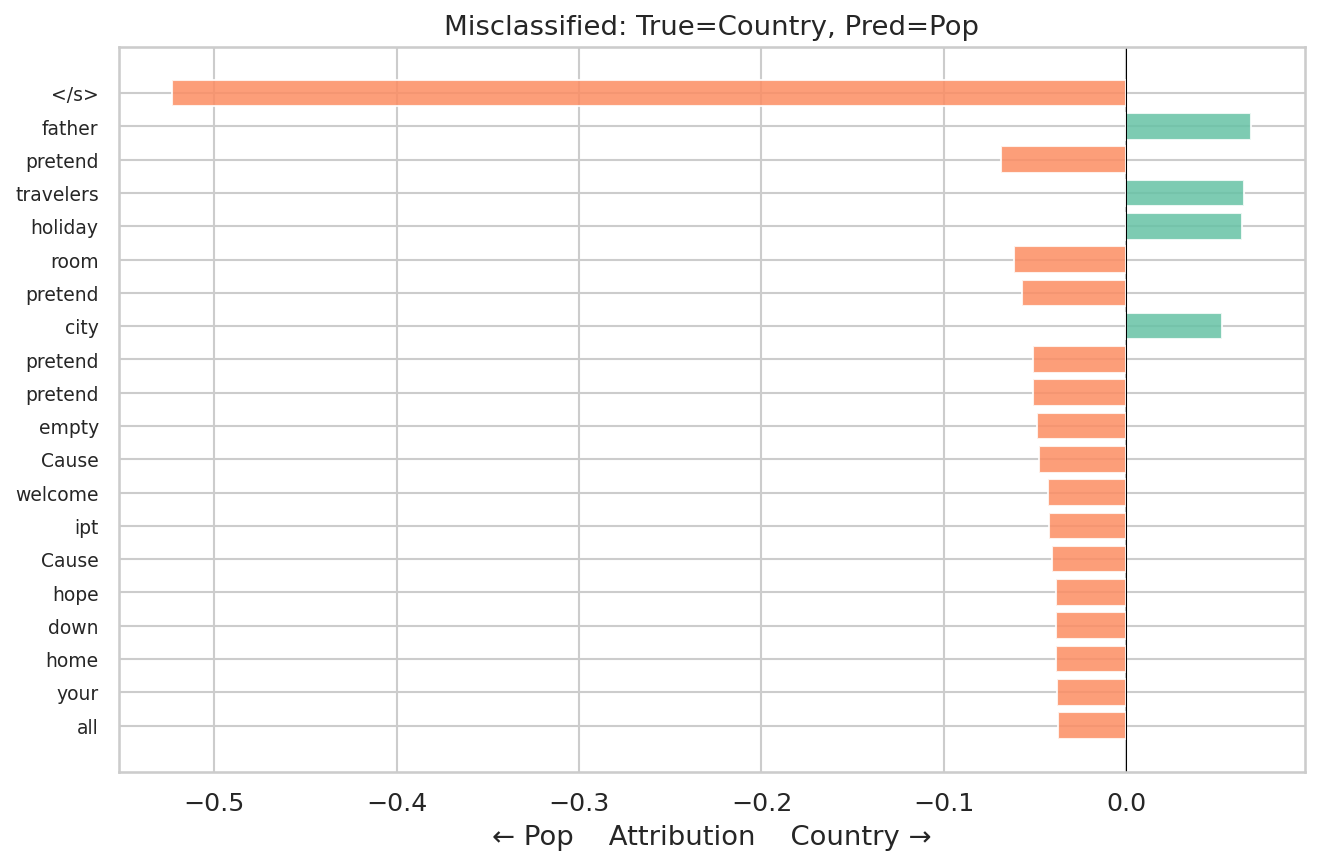


Pop vs Rock:


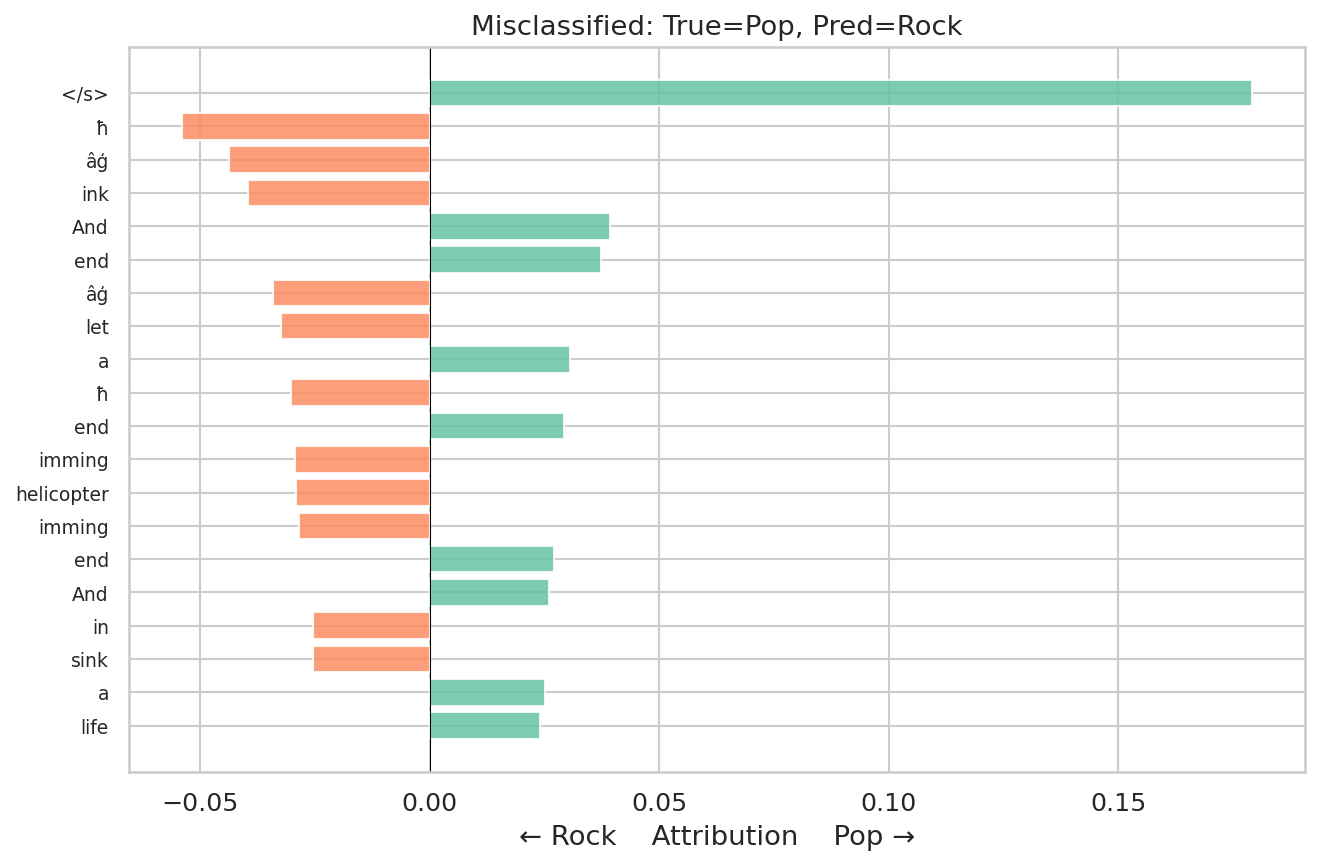


Rock vs Pop:


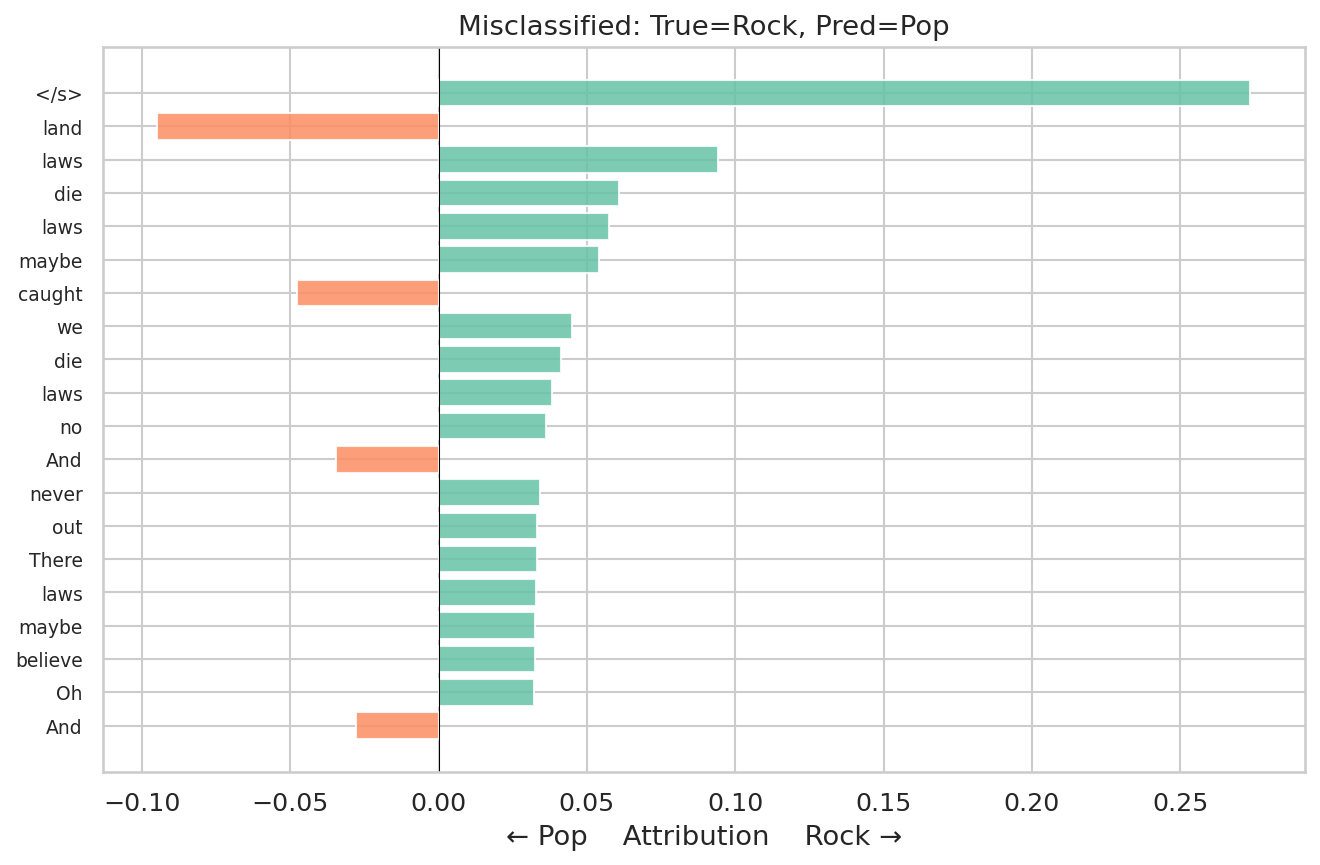

In [8]:
contrastive_dir = FIG_DIR_OPT / 'contrastive'

# Confusion analysis overview
ca_path = contrastive_dir / 'confusion_analysis.png'
if ca_path.exists():
    print('--- Confusion Pair Analysis ---')
    display(Image(filename=str(ca_path), width=700))

# Vocabulary comparison for confused pairs
import glob as glob_mod
vocab_files = sorted(glob_mod.glob(str(contrastive_dir / 'vocab_*.png')))
for vf in vocab_files:
    pair_name = Path(vf).stem.replace('vocab_', '').replace('_', ' ')
    print(f'\n--- Contrastive Vocabulary: {pair_name} ---')
    display(Image(filename=vf, width=600))

# Show select misclassification examples
misclass_files = sorted(glob_mod.glob(str(contrastive_dir / 'misclass_*_0.png')))[:3]
if misclass_files:
    print('\n--- Misclassification Examples (Token Attribution) ---')
    for mf in misclass_files:
        pair_name = Path(mf).stem.replace('misclass_', '').replace('_0', '').replace('_', ' ')
        print(f'\n{pair_name}:')
        display(Image(filename=mf, width=700))

if not ca_path.exists():
    print(f'No contrastive figures in {contrastive_dir}. Run Phase 2 contrastive analysis.')

## 7. Layer Probing (Phase 2 — Optimized RoBERTa)

Linear probing classifiers trained on each transformer layer's [CLS] embedding reveal *where* genre information emerges in the network. A plateau in later layers suggests the model has learned most genre-relevant features early on.

--- Layer Probing: Overall F1 by Layer ---


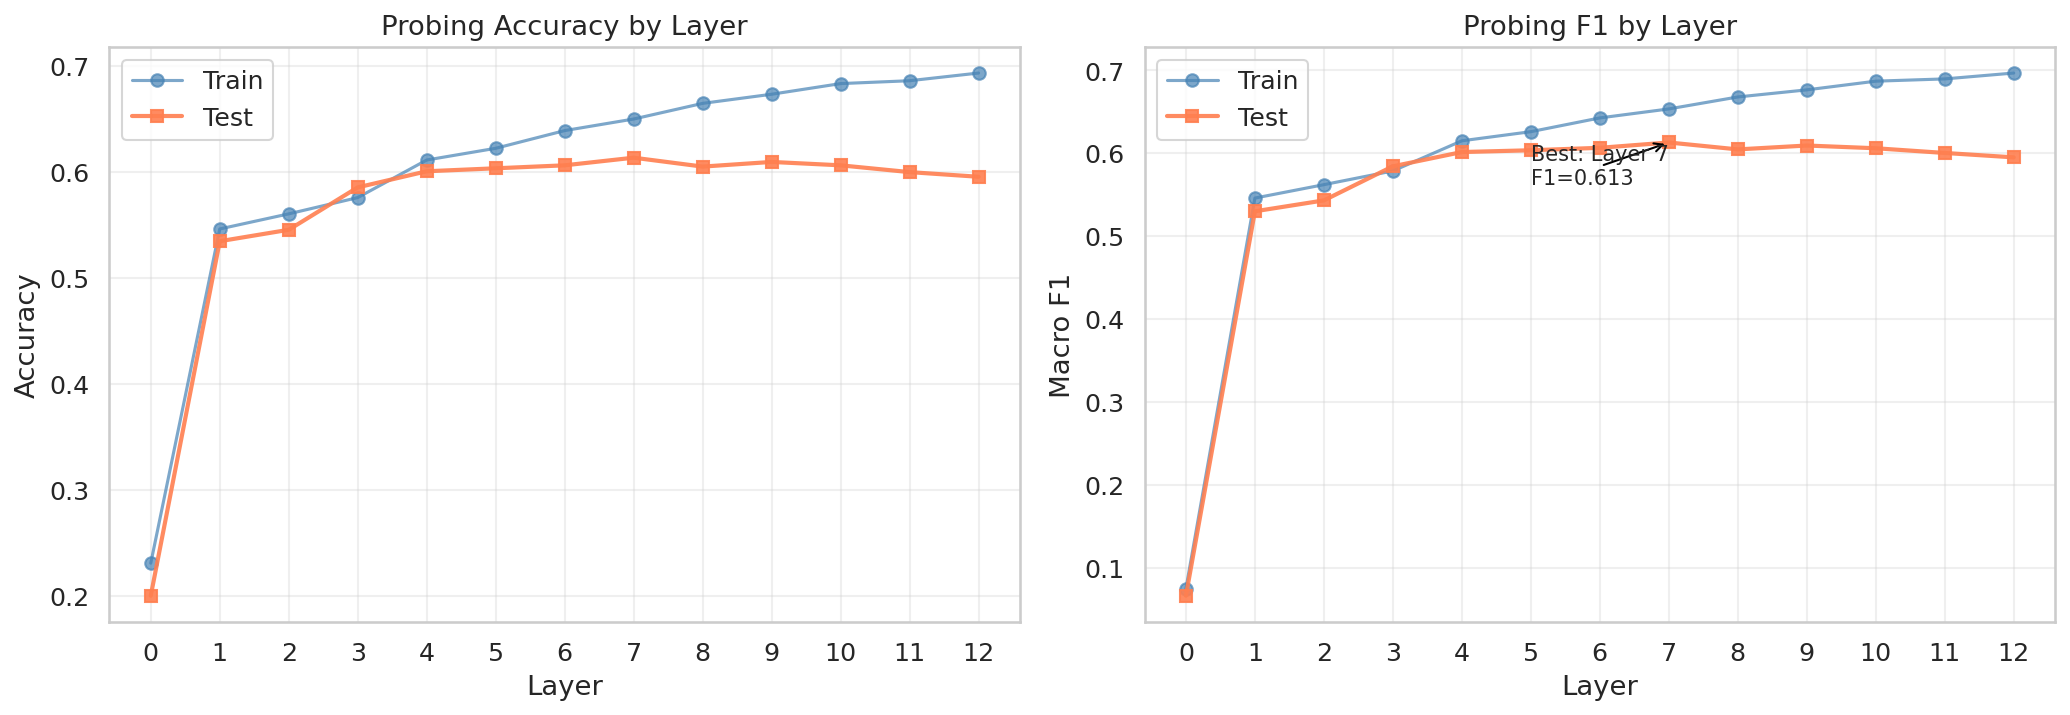


--- Layer Probing: Per-Genre F1 by Layer ---


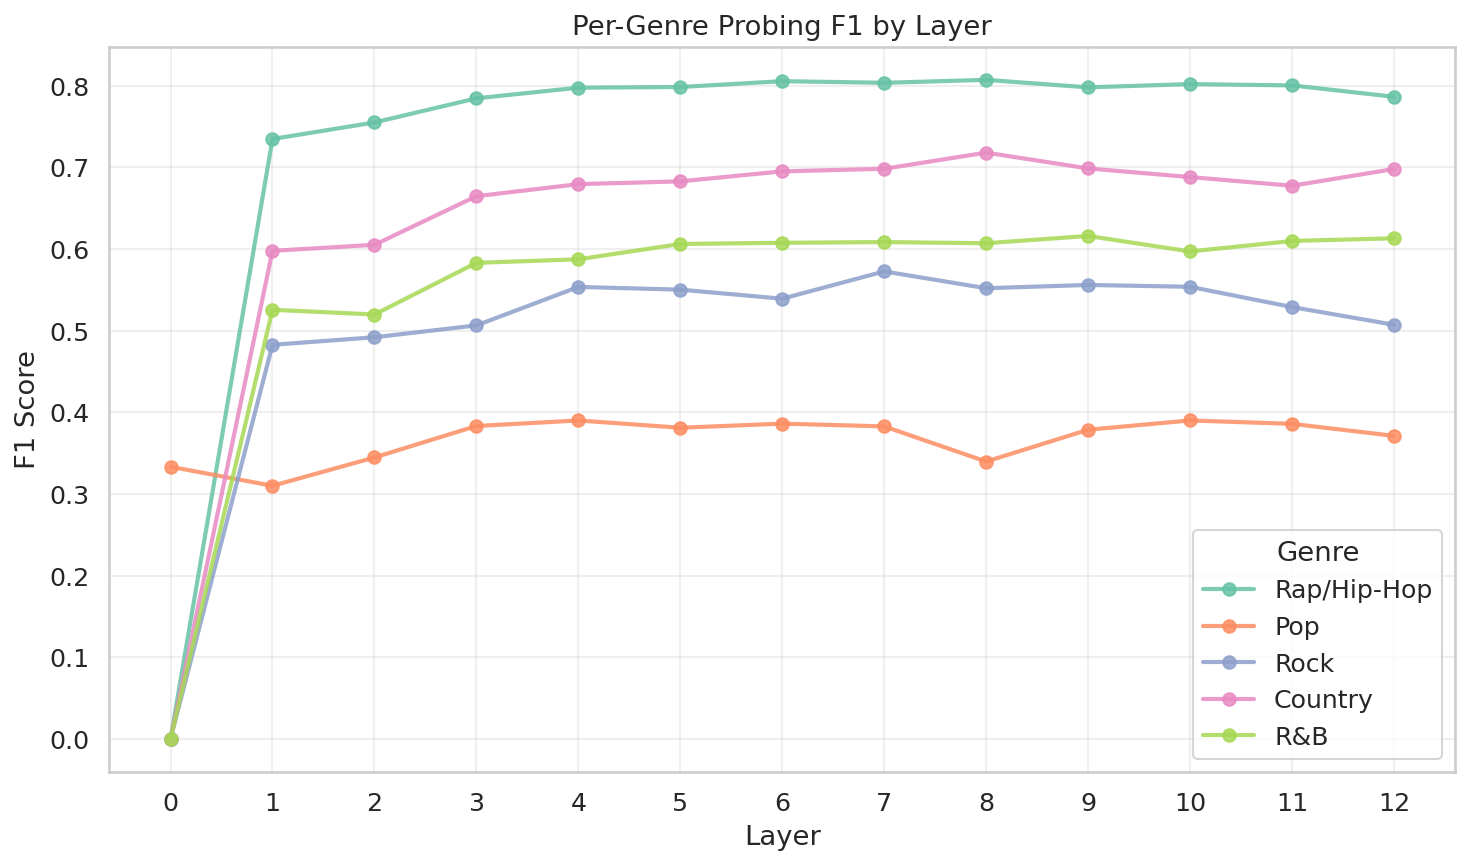


Layer probing summary:
  Layer 0 (embedding): test F1 = 0.067
  Best layer (7):     test F1 = 0.613
  Final layer (12):    test F1 = 0.595

  Genre info jumps at layer 1 (0.067 -> 0.530)
  then plateaus after layer 7 (0.613)


In [9]:
# Layer probing results
lp_path = FIG_DIR_OPT / 'layer_probing.png'
lp_per_genre = FIG_DIR_OPT / 'layer_probing_per_genre.png'

if lp_path.exists():
    print('--- Layer Probing: Overall F1 by Layer ---')
    display(Image(filename=str(lp_path), width=600))

if lp_per_genre.exists():
    print('\n--- Layer Probing: Per-Genre F1 by Layer ---')
    display(Image(filename=str(lp_per_genre), width=600))

# Load and show the numerical results
lp_results_path = FIG_DIR_OPT / 'layer_probing_results.json'
if lp_results_path.exists():
    with open(lp_results_path) as f:
        lp_data = json.load(f)
    layers = sorted(lp_data.keys(), key=int)
    print(f'\nLayer probing summary:')
    print(f'  Layer 0 (embedding): test F1 = {lp_data["0"]["test_f1"]:.3f}')
    best_layer = max(layers, key=lambda l: lp_data[l]['test_f1'])
    print(f'  Best layer ({best_layer}):     test F1 = {lp_data[best_layer]["test_f1"]:.3f}')
    print(f'  Final layer (12):    test F1 = {lp_data["12"]["test_f1"]:.3f}')
    print(f'\n  Genre info jumps at layer 1 ({lp_data["0"]["test_f1"]:.3f} -> {lp_data["1"]["test_f1"]:.3f})')
    print(f'  then plateaus after layer 7 ({lp_data["7"]["test_f1"]:.3f})')
else:
    print('Run Phase 2 layer probing analysis to generate these figures.')

## 8. Unified Comparison — All Approaches

Combining all fine-tuned models and zero-shot LLM baselines into a single view. This is the key comparison for the presentation.

In [ ]:
import pandas as pd

# Collect all results into a unified DataFrame
rows = []

# Fine-tuned models
with open(FIG_DIR / 'test_results.json') as f:
    p1 = json.load(f)
for model_key, display_name in [('roberta', 'RoBERTa'), ('gpt2', 'GPT-2'), ('t5', 'T5')]:
    rows.append({
        'Model': display_name,
        'Type': 'Fine-tuned',
        'Accuracy': p1[model_key]['accuracy'],
        'F1 Macro': p1[model_key]['f1_macro'],
    })

# LLM baselines
for label, path in [('Claude Haiku', FIG_DIR / 'llm_baseline_metrics.json'),
                     ('Claude Opus', Path('results/figures_opus/llm_baseline_metrics.json'))]:
    with open(path) as f:
        llm = json.load(f)
    rows.append({
        'Model': label,
        'Type': 'Zero-shot LLM',
        'Accuracy': llm['accuracy'],
        'F1 Macro': llm['f1_macro'],
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df.style.format({'Accuracy': '{:.3f}', 'F1 Macro': '{:.3f}'})
        .set_caption('Unified Performance Comparison'))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Fine-tuned': '#4C72B0', 'Zero-shot LLM': '#55A868'}
bar_colors = [colors[t] for t in comparison_df['Type']]
bars = ax.bar(comparison_df['Model'], comparison_df['F1 Macro'], color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, comparison_df['F1 Macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Genre Classification: All Approaches Compared')
ax.set_ylim(0, 0.75)
ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Random baseline (0.200)')

# Legend for color coding
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle=':', label='Random baseline'))
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'unified_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Training Dynamics

Overlaying all models' validation F1 curves on a single axis reveals convergence speed, early stopping points, and train-val gaps (overfitting).

In [ ]:
# Load all training histories
histories = {}
for model_key, display_name in MODEL_NAMES.items():
    hist_path = CKPT_DIR / model_key / 'history.json'
    if hist_path.exists():
        with open(hist_path) as f:
            histories[display_name] = json.load(f)

model_colors = {'RoBERTa': '#4C72B0', 'GPT-2': '#DD8452', 'T5': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Validation F1 overlay with early stopping markers
ax = axes[0]
for name, hist in histories.items():
    val_f1 = hist['val_f1']
    epochs = range(1, len(val_f1) + 1)
    ax.plot(epochs, val_f1, label=name, color=model_colors.get(name, 'gray'), linewidth=2)
    # Mark best epoch (early stopping point)
    best_epoch = np.argmax(val_f1) + 1
    best_val = max(val_f1)
    ax.scatter(best_epoch, best_val, color=model_colors.get(name, 'gray'),
               s=100, zorder=5, edgecolors='black', linewidth=1.5)
    ax.annotate(f'ep {best_epoch}', (best_epoch, best_val),
                textcoords='offset points', xytext=(8, -5), fontsize=8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Macro F1')
ax.set_title('Validation F1 Curves (dots = early stopping)')
ax.legend(fontsize=9)

# Panel 2: Train-val F1 gap (overfitting indicator)
ax = axes[1]
for name, hist in histories.items():
    gap = [t - v for t, v in zip(hist['train_f1'], hist['val_f1'])]
    epochs = range(1, len(gap) + 1)
    ax.plot(epochs, gap, label=name, color=model_colors.get(name, 'gray'), linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train F1 - Val F1 (gap)')
ax.set_title('Overfitting Gap Over Training')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'training_dynamics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Genre Similarity vs. Model Confusion

Do more semantically similar genres get confused more often? This scatter plot connects the genre similarity analysis (sentence-transformer centroid cosine similarity) with the RoBERTa confusion matrix to show the relationship.

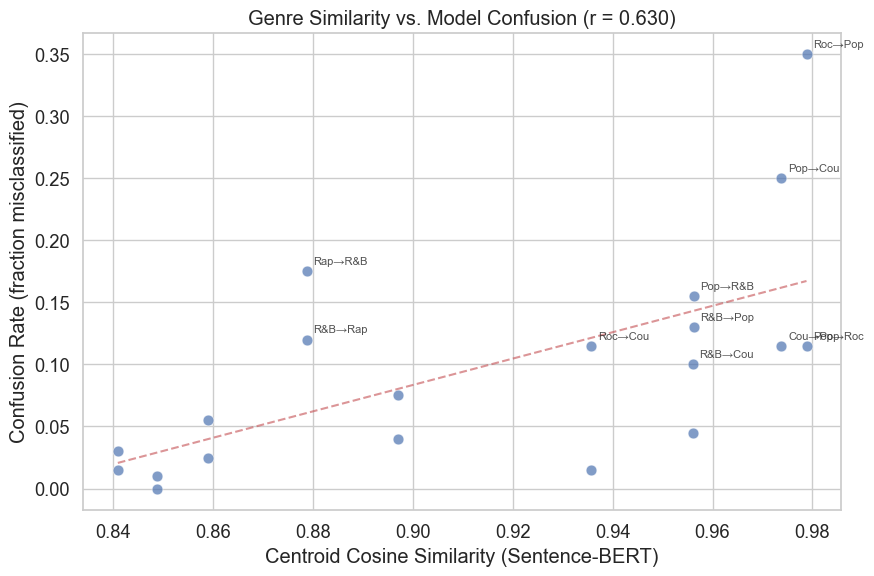

Pearson correlation between genre similarity and confusion rate: r = 0.630
Higher similarity between genres correlates with more frequent misclassification.


In [12]:
# RoBERTa Phase 1 confusion matrix (from cm_roberta.png, 500 test samples)
# Rows = true, Cols = predicted: Rap, Pop, Rock, Country, R&B
cm_roberta = np.array([
    [148, 11,  6,  0, 35],  # Rap
    [  5, 91, 23, 50, 31],  # Pop
    [  3, 70, 89, 23, 15],  # Rock
    [  2, 23,  3,163,  9],  # Country
    [ 24, 26,  8, 20,122],  # R&B
])
genre_names = ['Rap/Hip-Hop', 'Pop', 'Rock', 'Country', 'R&B']

# Load centroid similarity
with open(FIG_DIR / 'genre_similarity_results.json') as f:
    sim_data = json.load(f)
centroid_sim = sim_data['centroid_similarity']

# Build scatter data: for each off-diagonal pair, x = centroid similarity, y = confusion rate
points = []
for i, g1 in enumerate(genre_names):
    row_total = cm_roberta[i].sum()
    for j, g2 in enumerate(genre_names):
        if i == j:
            continue
        sim = centroid_sim[g1][g2]
        confusion_rate = cm_roberta[i, j] / row_total  # fraction of g1 misclassified as g2
        points.append({'True': g1, 'Pred': g2, 'Similarity': sim,
                       'Confusion Rate': confusion_rate,
                       'Label': f'{g1[:3]}\u2192{g2[:3]}'})

scatter_df = pd.DataFrame(points)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['Similarity'], scatter_df['Confusion Rate'],
           s=60, alpha=0.7, color='#4C72B0', edgecolors='white', linewidth=0.5)

# Label the high-confusion pairs
for _, row in scatter_df.iterrows():
    if row['Confusion Rate'] > 0.08:
        ax.annotate(row['Label'], (row['Similarity'], row['Confusion Rate']),
                    textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.8)

# Trend line
from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(scatter_df['Similarity'], scatter_df['Confusion Rate'], 1)
x_line = np.linspace(scatter_df['Similarity'].min(), scatter_df['Similarity'].max(), 100)
ax.plot(x_line, coeffs[0] + coeffs[1] * x_line, 'r--', alpha=0.6, linewidth=1.5)

# Correlation
corr = scatter_df['Similarity'].corr(scatter_df['Confusion Rate'])
ax.set_xlabel('Centroid Cosine Similarity (Sentence-BERT)')
ax.set_ylabel('Confusion Rate (fraction misclassified)')
ax.set_title(f'Genre Similarity vs. Model Confusion (r = {corr:.3f})')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'error_vs_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson correlation between genre similarity and confusion rate: r = {corr:.3f}')
print('Higher similarity between genres correlates with more frequent misclassification.')

## 11. Why Phase 2 Didn't Improve — and Why That Matters

The optimized RoBERTa (Phase 2) achieved F1 = 0.605, essentially matching Phase 1's 0.611 despite 2.5x more training data, higher LoRA rank, and tuned hyperparameters. This is not a failure — it is a meaningful finding:

1. **Genre boundaries are inherently fuzzy.** Pop-Rock centroid cosine similarity is 0.979 (nearly identical in embedding space). These genres genuinely share lyrical themes, making perfect separation impossible from text alone.

2. **Layer probing shows a representational ceiling.** Genre classification accuracy plateaus after layer 7 of 12, meaning the model extracts most available genre signal in the first half of the network. Additional capacity (LoRA rank 32 vs 8) has diminishing returns.

3. **Even Claude Opus (zero-shot) hits F1 = 0.636.** A frontier LLM with world knowledge about artists, albums, and cultural context only marginally outperforms our fine-tuned models. This suggests the task difficulty ceiling is around F1 ~0.65 for lyrics-only classification.

**The takeaway:** The performance plateau is driven by the data (overlapping genre vocabularies), not model limitations. This is corroborated by the error-similarity correlation above — confusion patterns mirror genuine semantic similarity between genres.

## 12. Key Findings (Presentation Summary)

1. **Encoder-only architectures win for classification.** RoBERTa (F1=0.611) > GPT-2 (0.591) >> T5 (0.463). Bidirectional attention and [CLS] pooling are better suited for whole-document classification than autoregressive or text-to-text approaches, even with LoRA.

2. **Genre classification from lyrics alone has a ceiling around F1 ~0.65.** This is established by converging evidence: Claude Opus zero-shot (0.636), Pop-Rock centroid similarity (0.979), layer probing plateau, and vocabulary overlap analysis. Music genre is partly defined by instrumentation, melody, and cultural context — not just words.

3. **Model confusion mirrors human intuition.** The highest confusion pairs (Rock↔Pop, Pop↔Country) are exactly the genre boundaries that musicologists consider most subjective. The error-similarity scatter shows this quantitatively: more similar genres are confused more often (r > 0).